In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [165]:
df_AQS=pd.read_csv('LA_AQS_2023.csv')
df_AQS

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22155,6,37,1103,63301,1,34.06659,-118.22688,WGS84,Solar radiation,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
22156,6,37,1103,61104,1,34.06659,-118.22688,WGS84,Wind Direction - Resultant,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
22157,6,37,1103,61103,1,34.06659,-118.22688,WGS84,Wind Speed - Resultant,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
22158,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [166]:
df_Manua=pd.read_csv('ManuaLoa_CO2.csv')
df_Manua

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
786,2023,9,2023.7083,418.51,421.96,18,0.30,0.14
787,2023,10,2023.7917,418.82,422.12,27,0.47,0.17
788,2023,11,2023.8750,420.46,422.43,21,0.91,0.38
789,2023,12,2023.9583,421.86,422.56,20,0.70,0.30


# Plotting Practice

## i) A histogram of the O3 concentrations

In [167]:
df_o3 = df_AQS.loc[df_AQS['Parameter Name']=='Ozone']
df_o3_hourly=df_o3.loc[df_o3['Duration Description']=='1 HOUR']

# Date (Local), AQI
df_o3_hourly['Date (Local)']=pd.to_datetime(df_o3_hourly['Date (Local)'])

/var/folders/rv/6grd_c413pg00vmn_zyh8ms00000gn/T/ipykernel_19472/883206471.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o3_hourly['Date (Local)']=pd.to_datetime(df_o3_hourly['Date (Local)'])


In [168]:
df_o3_hourly.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
20,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
64,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
204,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
228,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
271,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


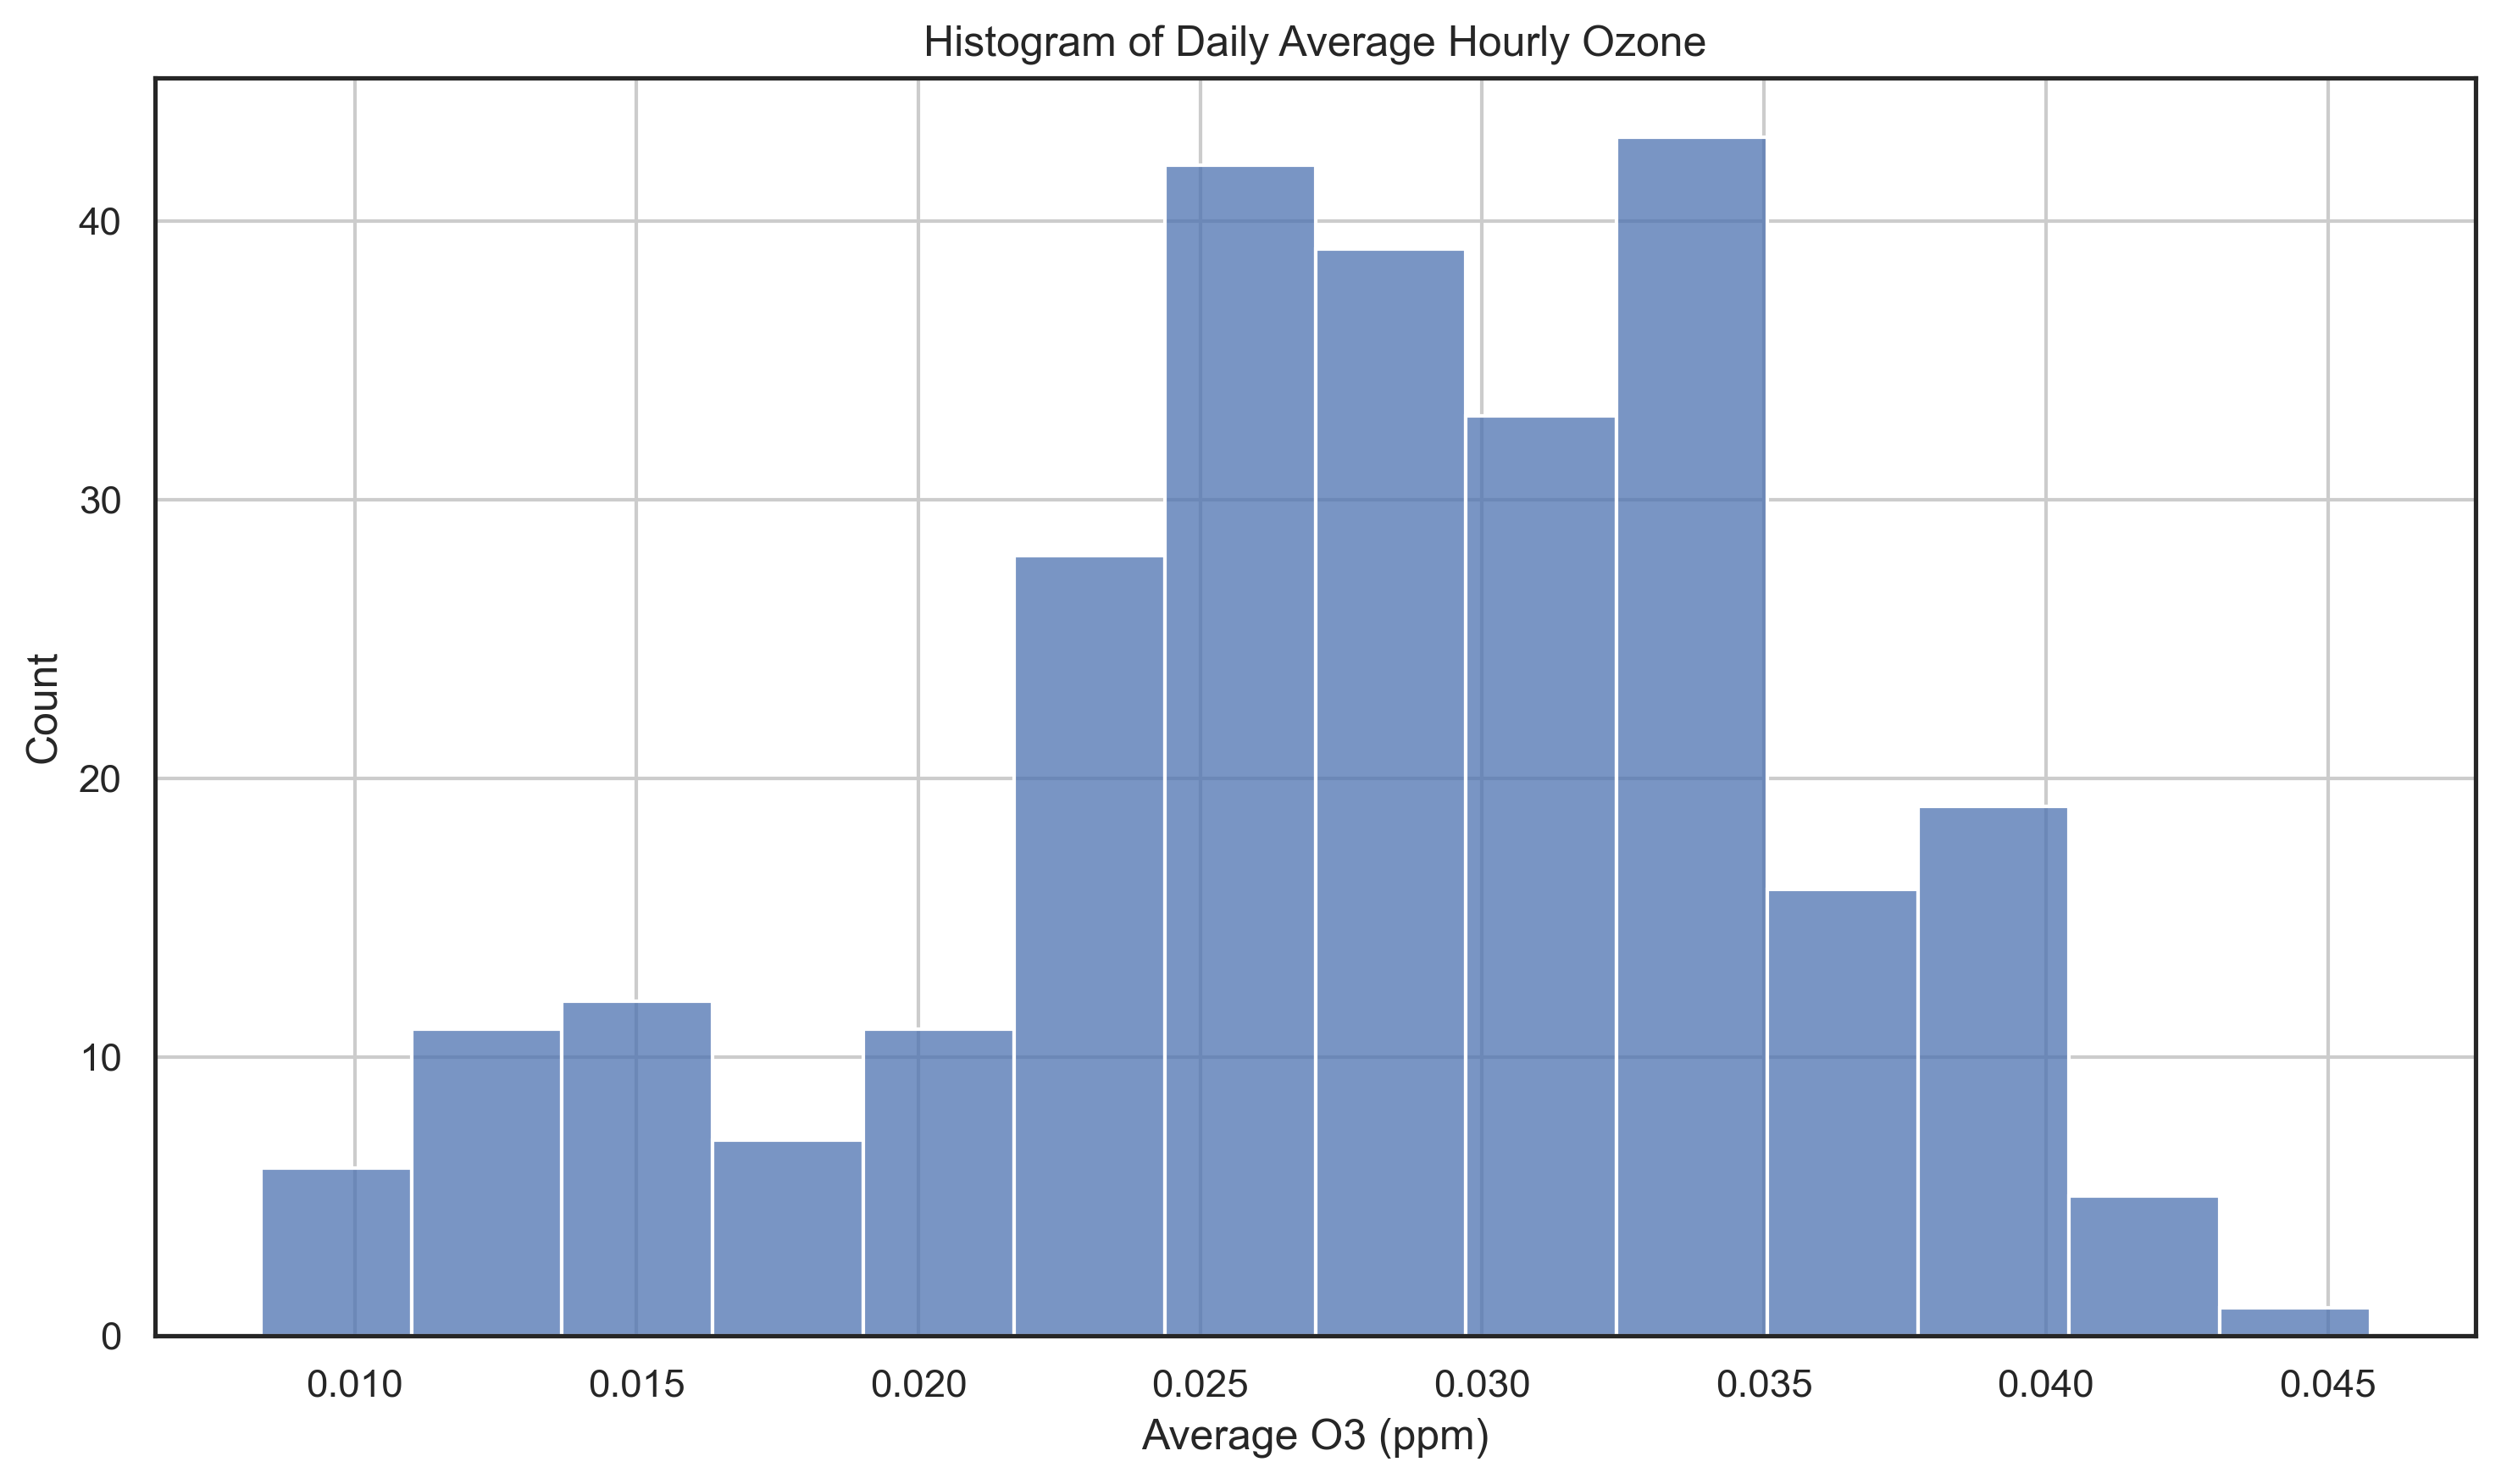

In [169]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6), dpi= 300)
sns.histplot(x='Arithmetic Mean', data=df_o3_hourly)
plt.xlabel('Average O3 (ppm)')
plt.ylabel('Count')
plt.title('Histogram of Daily Average Hourly Ozone')
plt.grid(True)
plt.tight_layout()
plt.show()

This plot shows that throughout the dataset, an average O3 concentration of ~0.025-0.035 ppm have the highest frequency of measurements as it has the highest count. 

## ii) A density plot of NO2 concentrations

In [170]:
df_no2 = df_AQS.loc[df_AQS['Parameter Name']=='Nitrogen dioxide (NO2)']
df_no2_hourly=df_no2.loc[df_no2['Duration Description']=='1 HOUR']

# Date (Local), AQI
df_no2_hourly['Date (Local)']=pd.to_datetime(df_no2_hourly['Date (Local)'])
df_no2_hourly.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
19,6,37,1103,42602,1,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
29,6,37,1103,42602,1,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
41,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
44,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,20,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


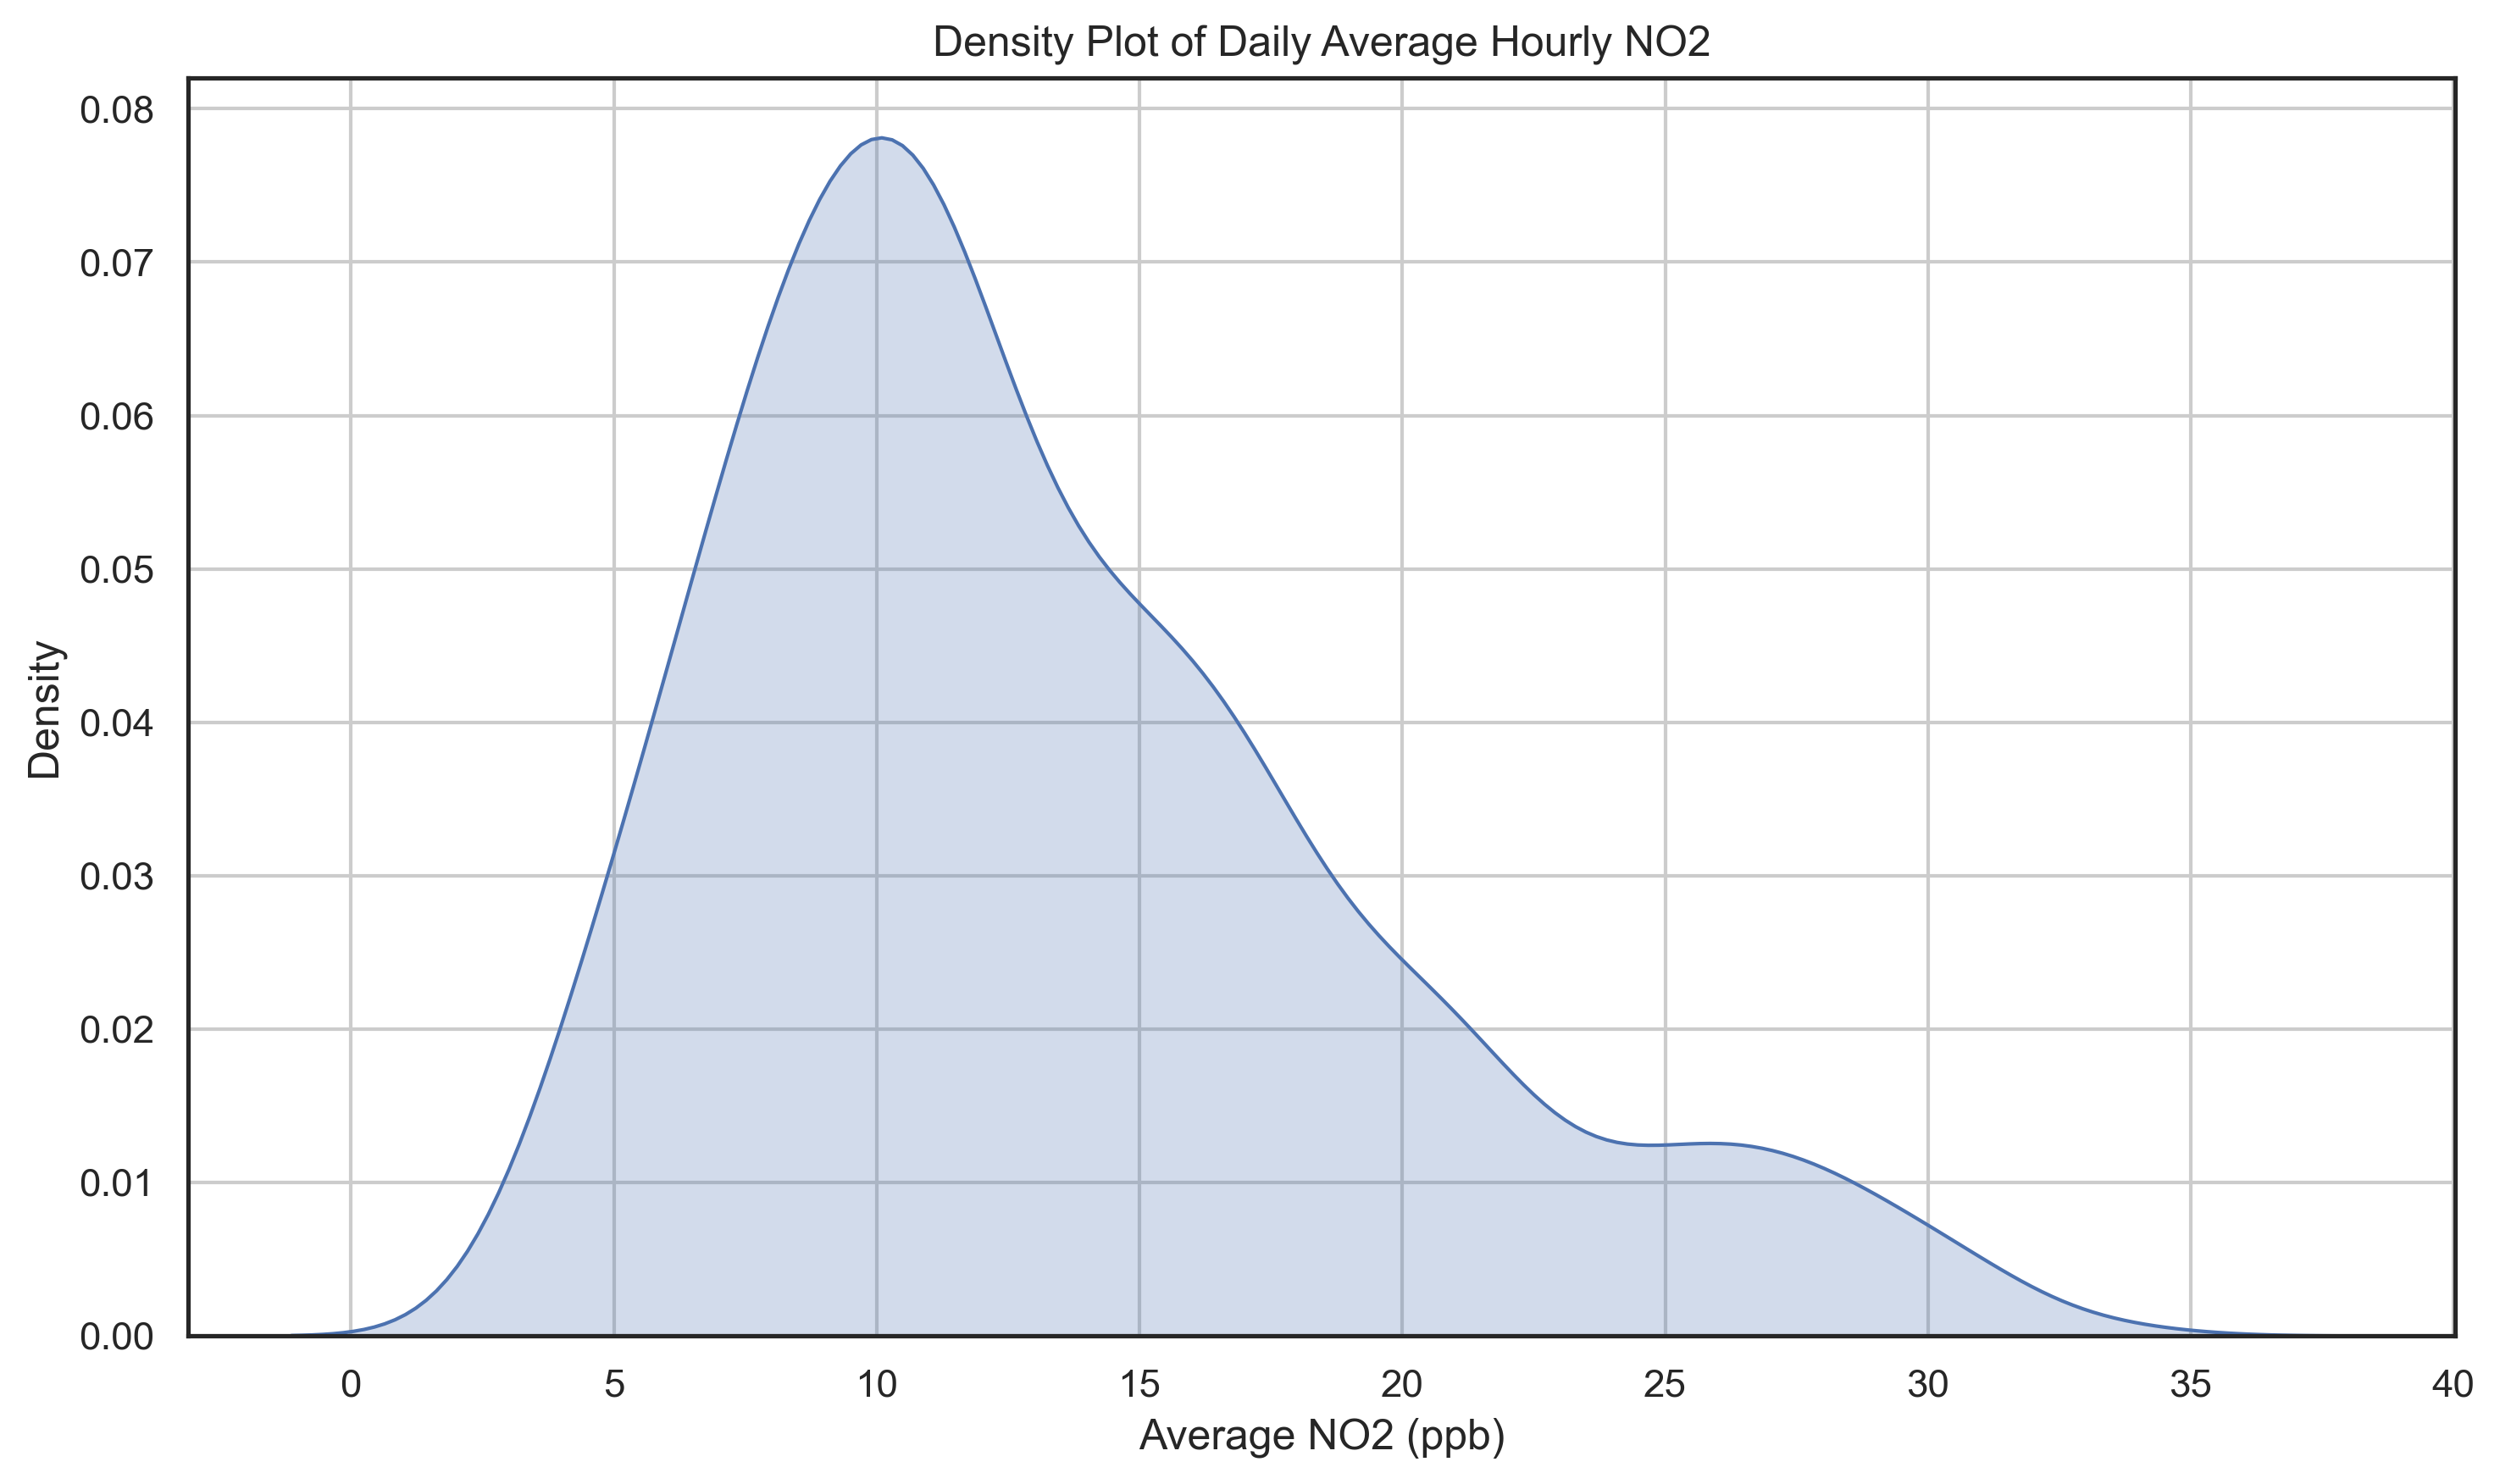

In [171]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6), dpi= 300)
sns.kdeplot(data=df_no2_hourly, x='Arithmetic Mean', fill=True)
plt.xlabel('Average NO2 (ppb)')
plt.ylabel('Density')
plt.title('Density Plot of Daily Average Hourly NO2')
plt.grid(True)
plt.tight_layout()
plt.show()

This plot shows that average NO2 most commonly is measured at around 10 ppb, however, the dataset is pretty spread out with a range between 0-35ppb. 

## iii) A scatter plot of O3 vs NO2 concentrations

In [172]:
# converts ppm to ppb

df_o3_hourly.loc[:, 'Arithmetic Mean']=df_o3_hourly['Arithmetic Mean'] * 1000

In [173]:
df_o3_hourly['Date (Local)'] = pd.to_datetime(df_o3_hourly['Date (Local)'])
df_no2_hourly['Date (Local)'] = pd.to_datetime(df_no2_hourly['Date (Local)'])

merged_df = pd.merge(df_o3_hourly, df_no2_hourly, on=['Date (Local)'], how='inner')
merged_df.head()

/var/folders/rv/6grd_c413pg00vmn_zyh8ms00000gn/T/ipykernel_19472/1865878899.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o3_hourly['Date (Local)'] = pd.to_datetime(df_o3_hourly['Date (Local)'])


,State Code_x,County Code_x,Site Number_x,Parameter Code_x,POC_x,Latitude_x,Longitude_x,Datum_x,Parameter Name_x,Duration Description_x,...,AQI_y,Daily Criteria Indicator_y,Tribe Name_y,State Name_y,County Name_y,City Name_y,Local Site Name_y,Address_y,MSA or CBSA Name_y,Data Source_y
0,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,20,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


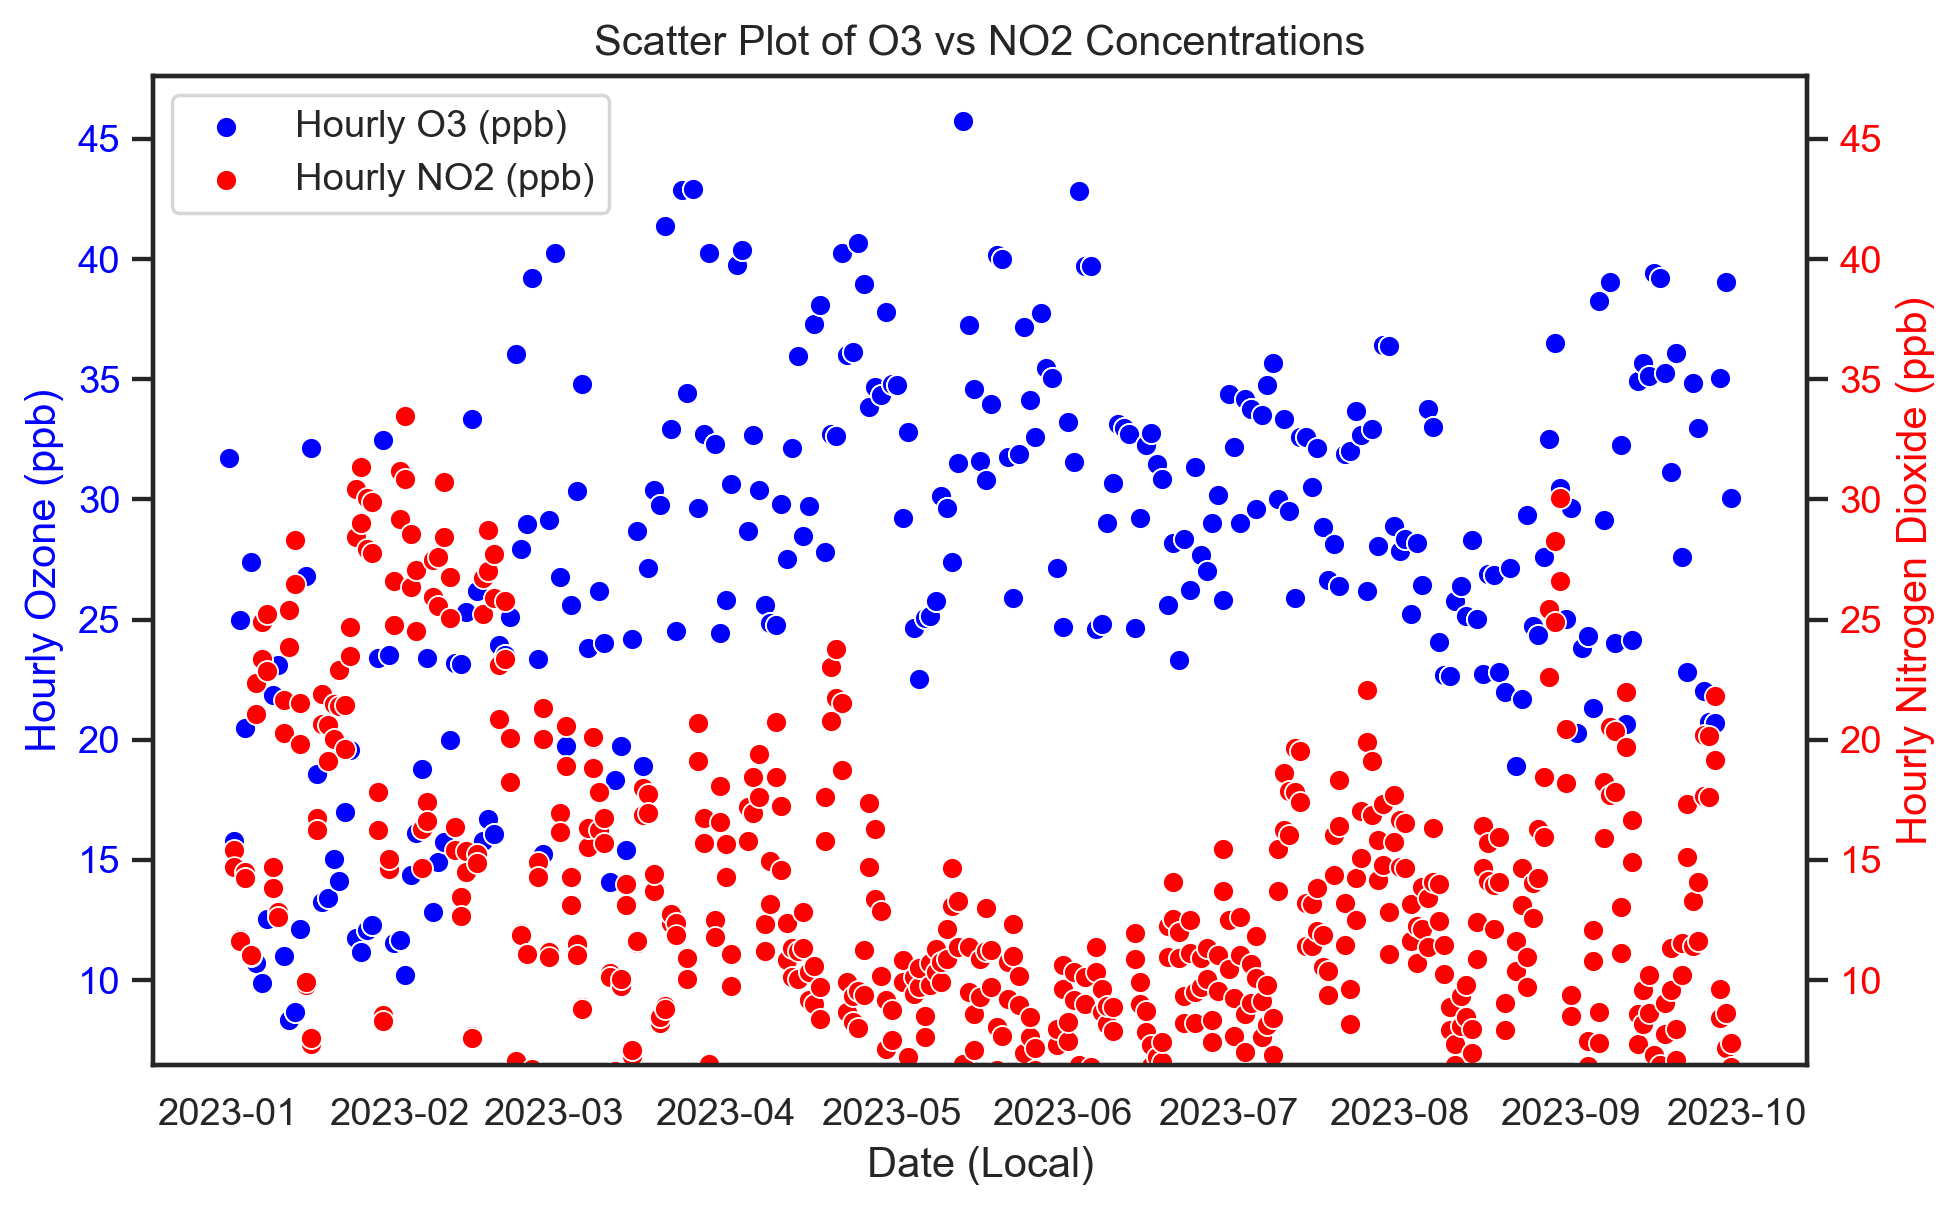

In [174]:
fig, ax1 = plt.subplots(figsize=(8, 5), dpi=250)

sns.scatterplot(data=merged_df, y="Arithmetic Mean_x", x="Date (Local)", label="Hourly O3 (ppb)", ax=ax1, color='blue')
ax1.set_ylabel("Hourly Ozone (ppb)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()

sns.scatterplot(data=merged_df, y="Arithmetic Mean_y", x="Date (Local)", label="Hourly NO2 (ppb)", ax=ax2, color='red')
ax2.set_ylabel("Hourly Nitrogen Dioxide (ppb)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove() 
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax2.set_ylim(ax1.get_ylim()) 

plt.title('Scatter Plot of O3 vs NO2 Concentrations')
ax2.grid(False)
ax1.grid(False)
plt.tight_layout()
plt.show()

This plot shows that ozone measures higher compared to nitrogen dioxide across this study period.

## iv) A barchart of the number of days per month with O3 > 35 ppb

In [175]:
df_o3_above35 = df_o3_hourly.loc[df_o3_hourly['Arithmetic Mean']>35]
df_o3_above35.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
4651,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4928,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
5235,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
7130,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
7337,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [176]:
df_o3_above35["month"] = df_o3_above35["Date (Local)"].dt.strftime("%B")

/var/folders/rv/6grd_c413pg00vmn_zyh8ms00000gn/T/ipykernel_19472/896950353.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o3_above35["month"] = df_o3_above35["Date (Local)"].dt.strftime("%B")


In [177]:
monthly=(df_o3_above35.groupby("month").size().reset_index(name="Date (Local)"))


In [178]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

/var/folders/rv/6grd_c413pg00vmn_zyh8ms00000gn/T/ipykernel_19472/3891951239.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly,x="month", y="Date (Local)", order=month_order, palette="tab10")


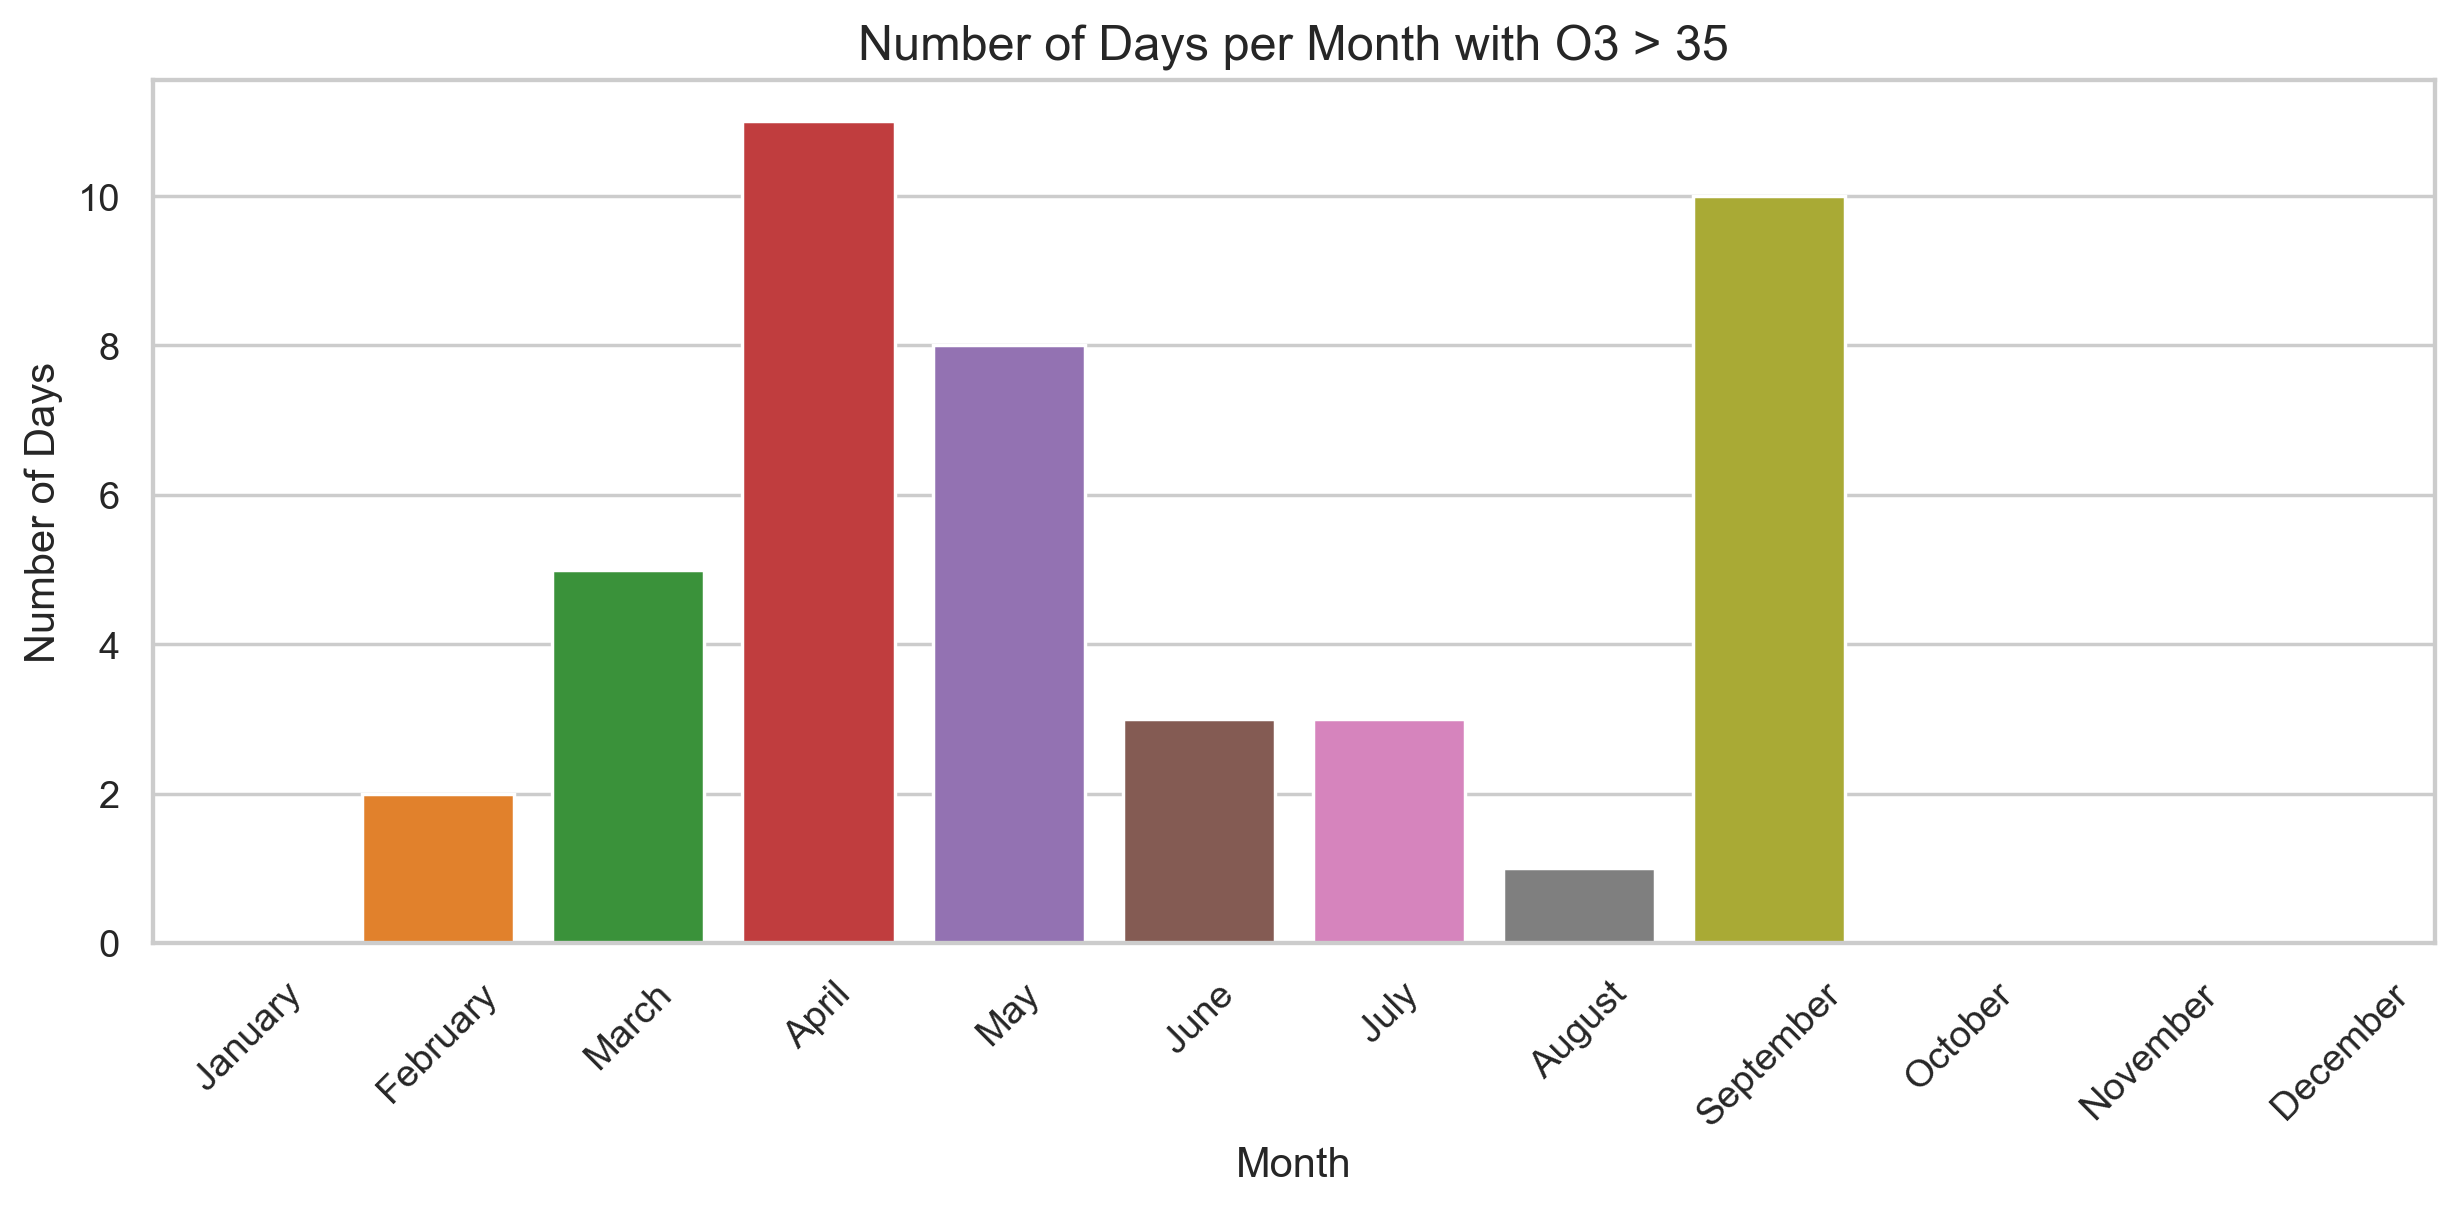

In [179]:
plt.figure(figsize=(10, 5), dpi=250)
sns.set_theme(style="whitegrid")
sns.barplot(data=monthly,x="month", y="Date (Local)", order=month_order, palette="tab10")

plt.title("Number of Days per Month with O3 > 35", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Days")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

This plot shows that April is a month where there are most days where ozone is above 35 ppb. In general, warmer months exhibit higher number of days where ozone is above 35 ppb while colder months (ie. Oct-January) have no days where ozone is measured higher than 35 ppb. 

# Mauna Loa CO2

## i) Make a scatterplot of average CO2 concentrations vs time (decimal date).

In [180]:
df_Manua

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
786,2023,9,2023.7083,418.51,421.96,18,0.30,0.14
787,2023,10,2023.7917,418.82,422.12,27,0.47,0.17
788,2023,11,2023.8750,420.46,422.43,21,0.91,0.38
789,2023,12,2023.9583,421.86,422.56,20,0.70,0.30


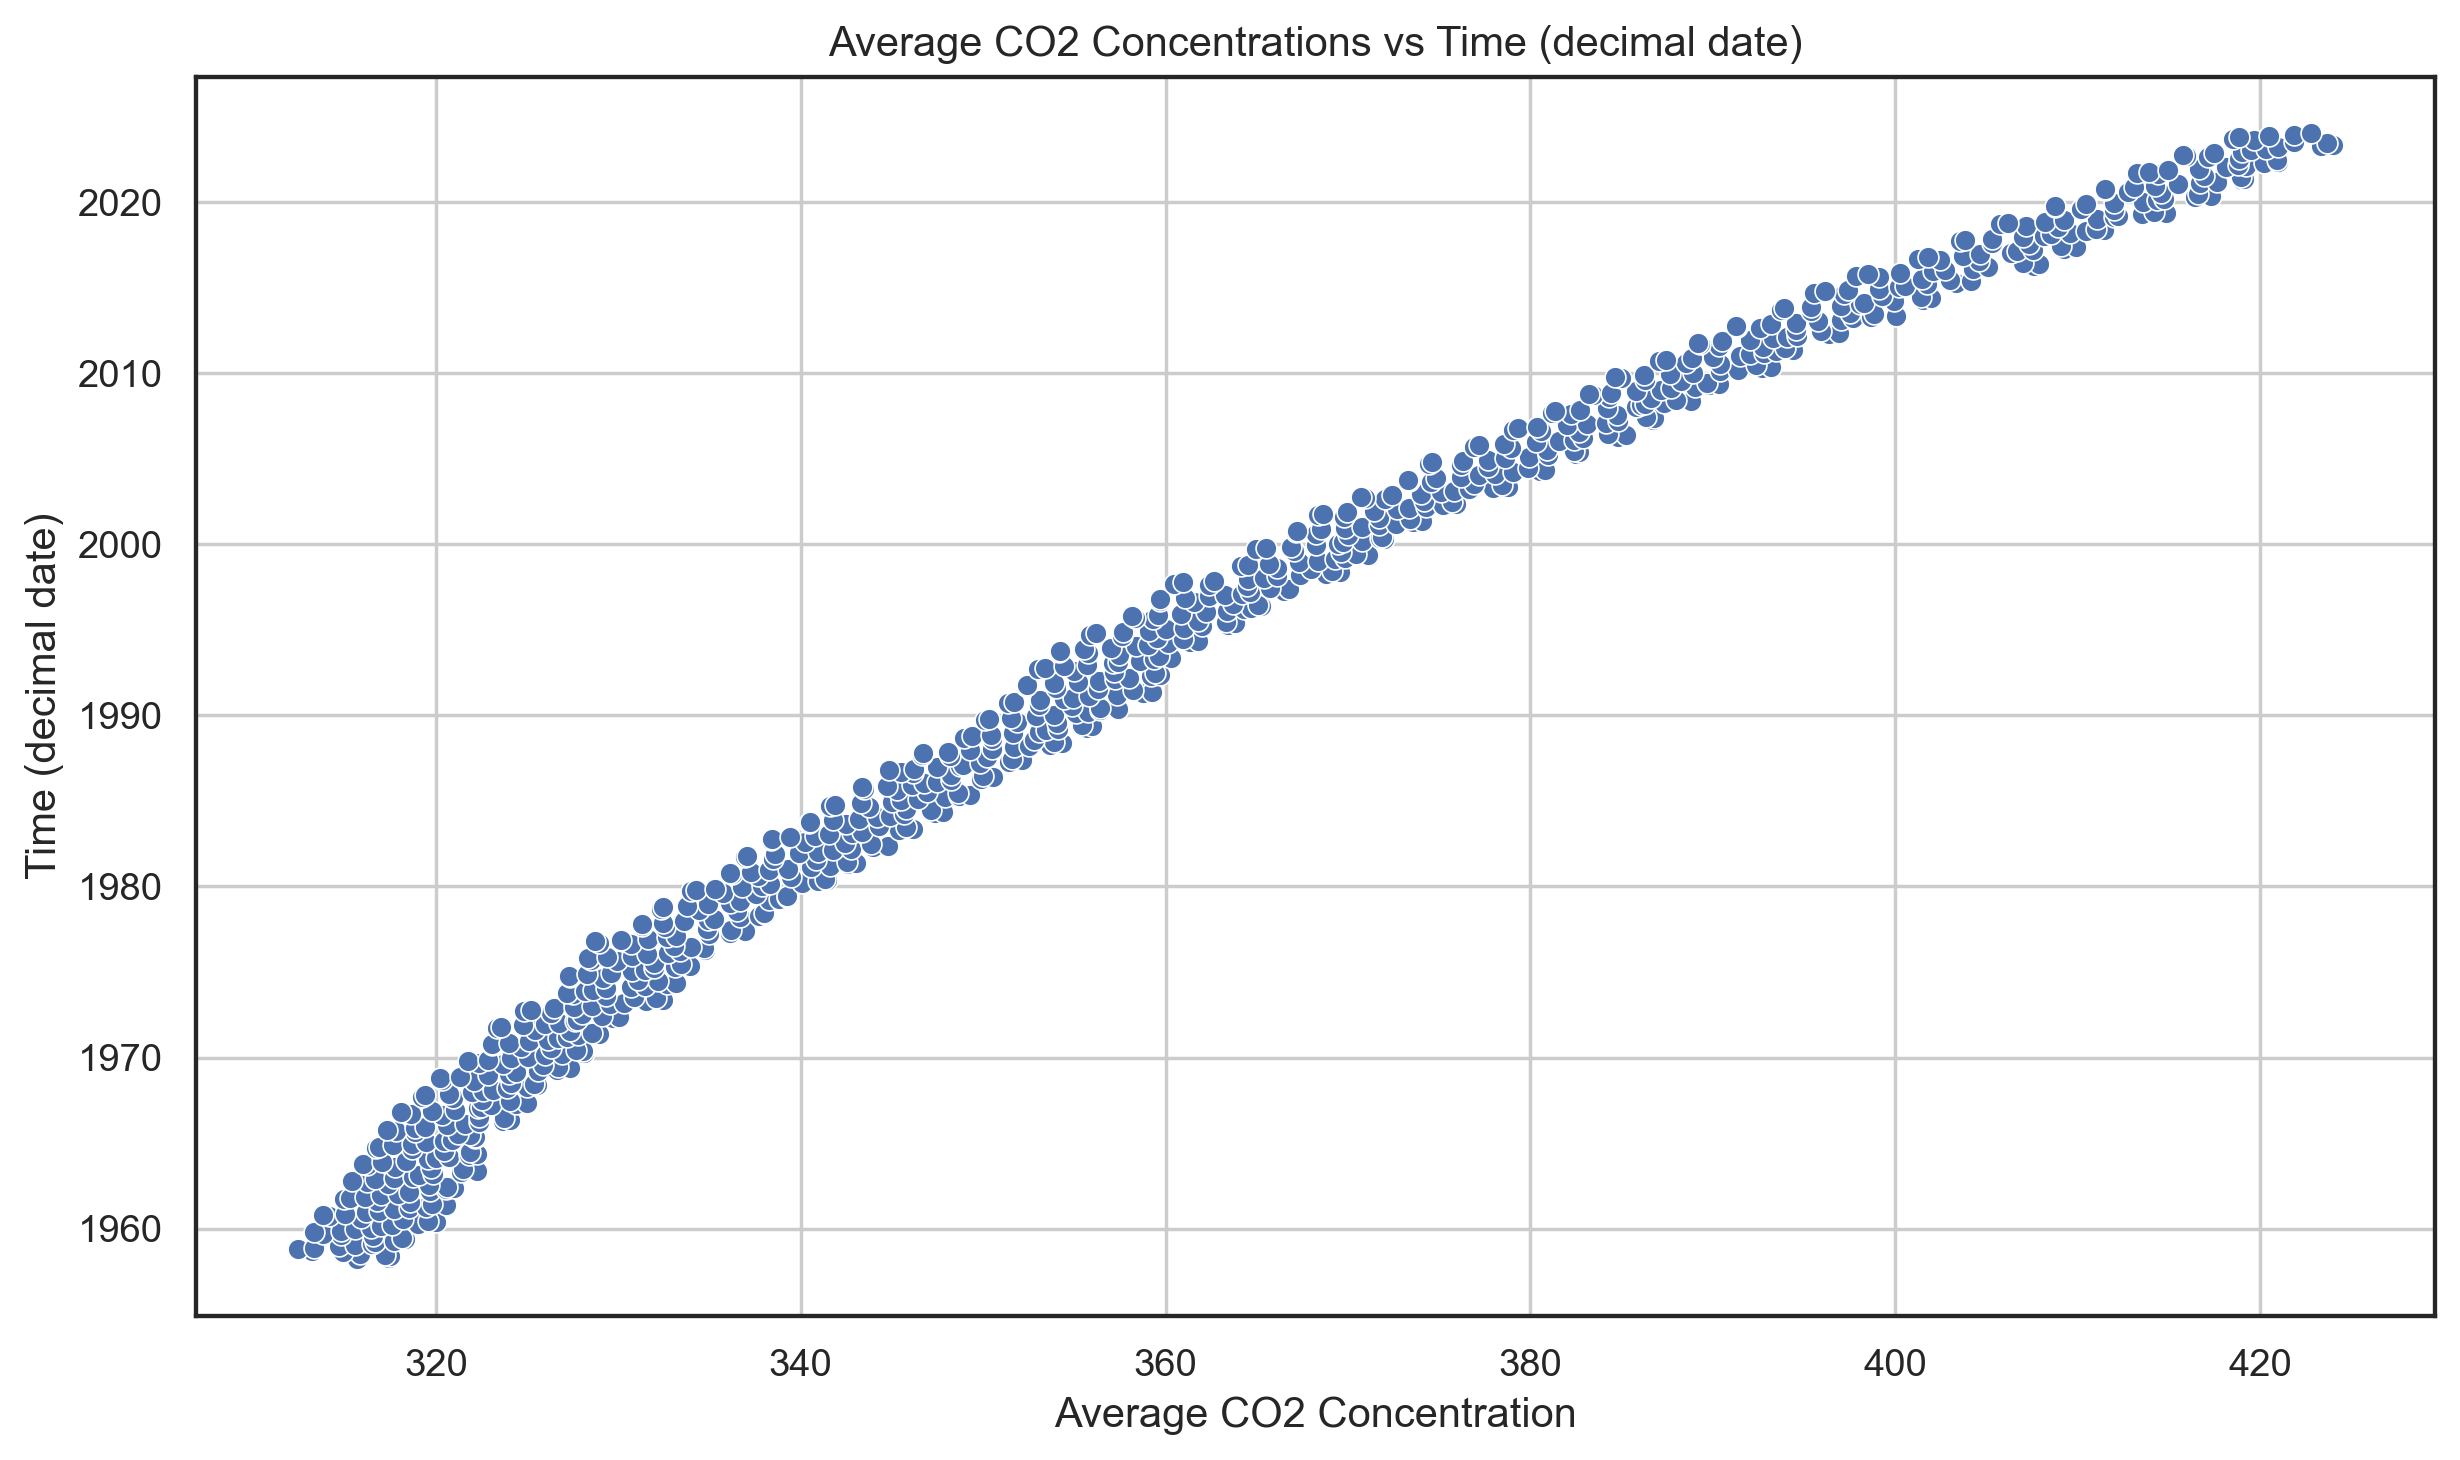

In [181]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6), dpi= 250)
sns.scatterplot(data=df_Manua, x='average', y='decimal date')
plt.xlabel('Average CO2 Concentration')
plt.ylabel('Time (decimal date)')
plt.title('Average CO2 Concentrations vs Time (decimal date)')
plt.grid(True)
plt.tight_layout()
plt.show()

## ii) Make the worst possible scatterplot of average CO2 concentrations vs time (decimal date).

In [182]:
dark_rdgn = sns.blend_palette(["#FF0000", "#00FF00"], as_cmap=True)

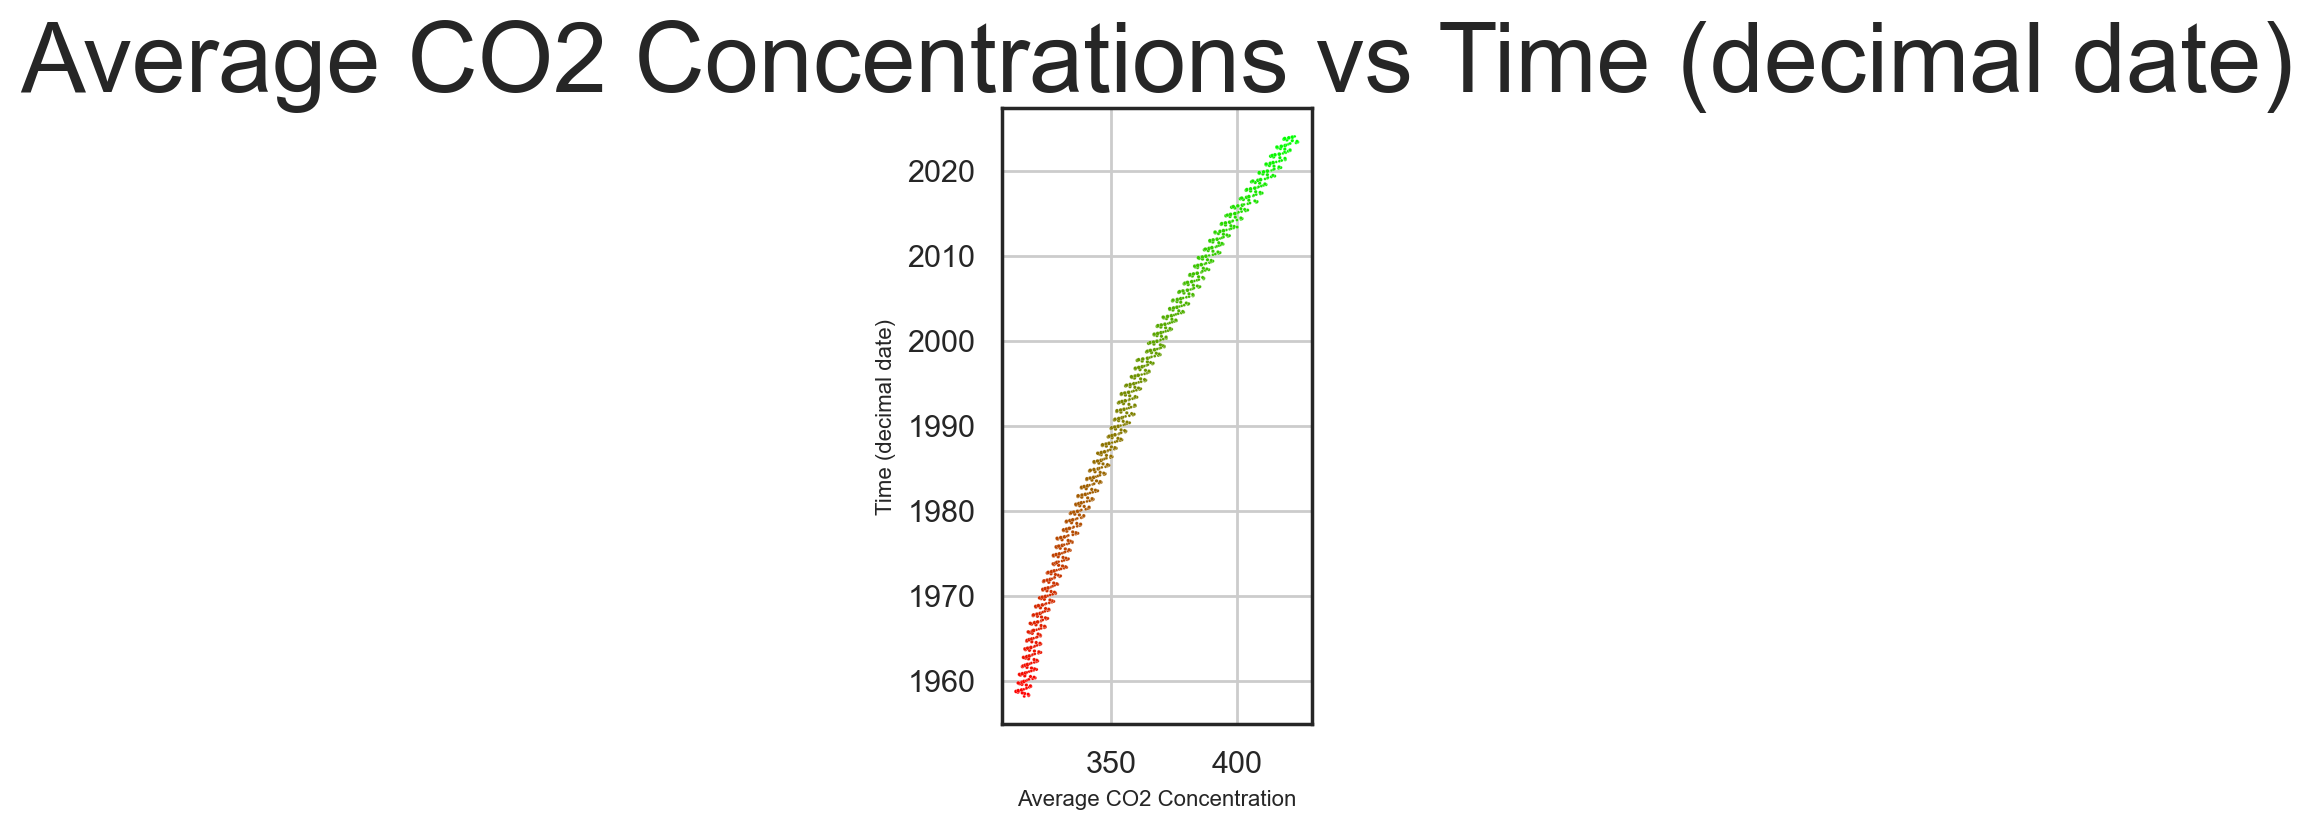

In [183]:
sns.set_theme(style="white")
plt.figure(figsize=(2, 4), dpi= 200)
sns.scatterplot(data=df_Manua, x='average', y='decimal date', hue="decimal date", size='month', sizes=(1, 2), palette=dark_rdgn, legend=False)
plt.xlabel('Average CO2 Concentration', size=8)
plt.ylabel('Time (decimal date)', size=8)
plt.title('Average CO2 Concentrations vs Time (decimal date)', size=35)
plt.grid(True)
plt.show()

### a. Make the figure technically correct (it has to show CO2 concentrations vs time), but horrible

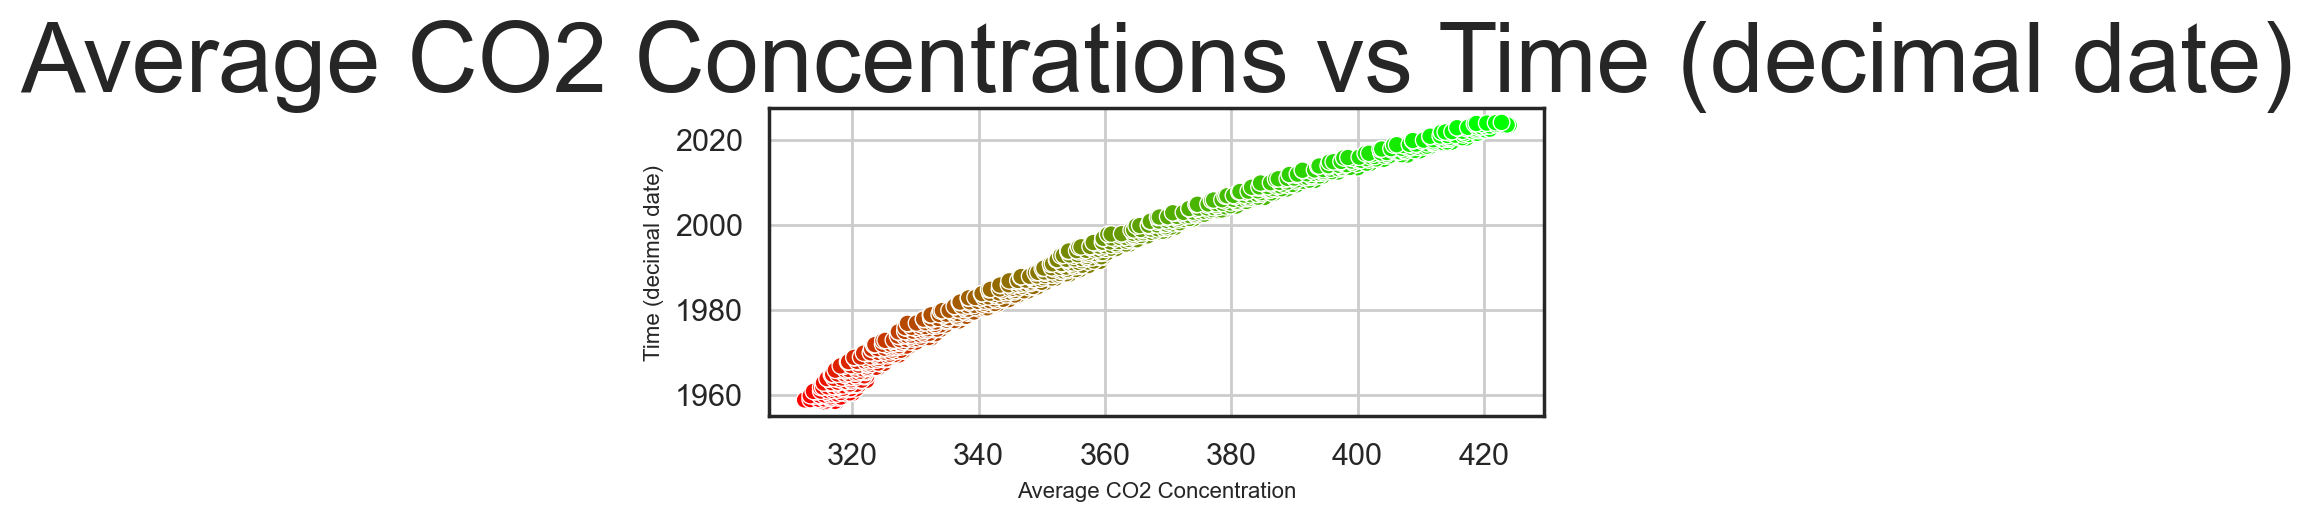

In [184]:
sns.set_theme(style="white")
plt.figure(figsize=(5, 2), dpi= 200)
sns.scatterplot(data=df_Manua, x='average', y='decimal date', hue="decimal date", palette=dark_rdgn, legend=False)
plt.xlabel('Average CO2 Concentration', size=8)
plt.ylabel('Time (decimal date)', size=8)
plt.title('Average CO2 Concentrations vs Time (decimal date)', size=35)
plt.grid(True)
plt.show()